In [57]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

df = pd.read_csv("./data_cleaned/mines.csv")
df.drop(columns=["MagSus_SI"], inplace=True)
df.head()

,province,longitude,latitude,Vp_100_kms,Density_gcc,elevation,SiO2_pct,Al2O3_pct,Fe2O3_pct,MgO_pct,...,Cobalt,Copper,Diamond,Gold,Graphite,Lithium,Nickel,Rare Earth Elements (REE),Silver,Uranium
0,Alberta,-119.259533,54.028620,6.156535,2.741558,1526.0,10.080060,1.344176,0.915702,0.782849,...,0,0,0,0,0,0,0,0,0,0
1,Alberta,-119.178389,53.938609,6.003050,2.702220,997.0,10.509113,1.494849,1.472888,0.639297,...,0,0,0,0,0,0,0,0,0,0
2,Alberta,-119.166700,54.033300,6.156684,2.741491,1256.0,10.887126,1.341847,0.928192,0.781493,...,0,0,0,0,0,0,0,0,0,0
3,Alberta,-117.508710,53.093082,5.870413,2.768604,1757.0,31.763702,5.646134,7.142402,0.160068,...,0,0,0,0,0,0,0,0,0,0
4,Alberta,-117.460447,53.607195,5.845066,2.725312,1444.0,19.958529,4.739211,4.412431,0.395807,...,0,0,0,0,0,0,0,0,0,0


In [58]:
df['province'].value_counts()

province
Quebec                       221
Ontario                      199
British Columbia             179
Saskatchewan                  85
Alberta                       53
Manitoba                      48
Yukon                         29
Northwest Territories         20
New Brunswick                 15
Nunavut                       14
Newfoundland-and-Labrador      7
Newfoundland and Labrador      3
Name: count, dtype: int64

In [59]:
targets = [
    'Cobalt',
    'Copper',
    'Diamond',
    'Gold',
    'Graphite',
    'Lithium',
    'Nickel',
    'Rare Earth Elements (REE)',
    'Silver',
    'Uranium'
]
df_negatives = df[(df[targets] == 0).all(axis=1)]
df_negatives

,province,longitude,latitude,Vp_100_kms,Density_gcc,elevation,SiO2_pct,Al2O3_pct,Fe2O3_pct,MgO_pct,...,Cobalt,Copper,Diamond,Gold,Graphite,Lithium,Nickel,Rare Earth Elements (REE),Silver,Uranium
0,Alberta,-119.259533,54.028620,6.156535,2.741558,1526.0,10.080060,1.344176,0.915702,0.782849,...,0,0,0,0,0,0,0,0,0,0
1,Alberta,-119.178389,53.938609,6.003050,2.702220,997.0,10.509113,1.494849,1.472888,0.639297,...,0,0,0,0,0,0,0,0,0,0
2,Alberta,-119.166700,54.033300,6.156684,2.741491,1256.0,10.887126,1.341847,0.928192,0.781493,...,0,0,0,0,0,0,0,0,0,0
3,Alberta,-117.508710,53.093082,5.870413,2.768604,1757.0,31.763702,5.646134,7.142402,0.160068,...,0,0,0,0,0,0,0,0,0,0
4,Alberta,-117.460447,53.607195,5.845066,2.725312,1444.0,19.958529,4.739211,4.412431,0.395807,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843,Saskatchewan,-101.533499,50.458098,5.944863,2.797782,467.0,50.990180,13.133735,4.674761,3.120887,...,0,0,0,0,0,0,0,0,0,0
844,Yukon,-140.716111,64.439167,6.178433,2.800348,601.0,55.264300,6.070148,5.028210,4.448079,...,0,0,0,0,0,0,0,0,0,0
853,Yukon,-136.263611,62.123611,6.255065,2.827329,671.0,62.891190,15.360691,5.868689,2.648576,...,0,0,0,0,0,0,0,0,0,0
865,Yukon,-132.532500,61.974722,6.340107,2.848387,863.0,62.004550,14.538347,3.425441,1.948175,...,0,0,0,0,0,0,0,0,0,0


C:\Users\jylis\AppData\Local\Temp\ipykernel_2512\103862668.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


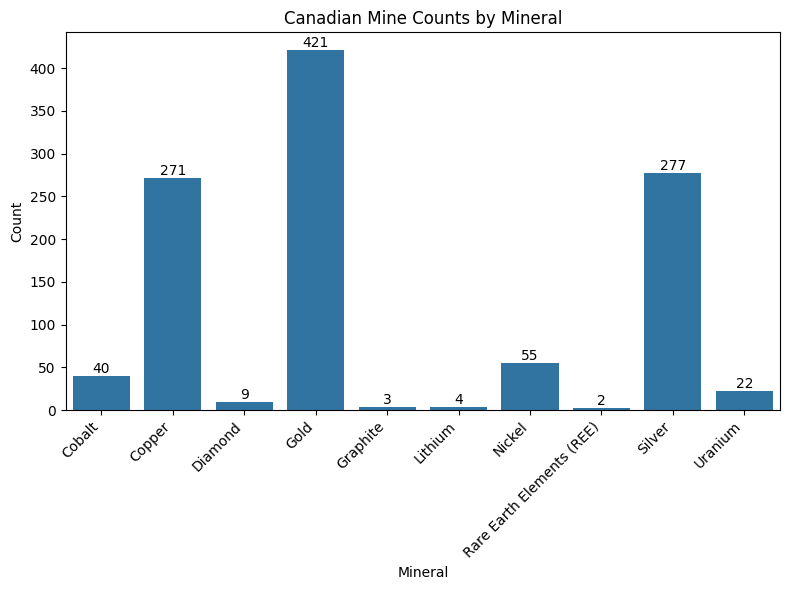

In [60]:
counts = df[targets].sum().reset_index()
counts.columns = ['Mineral', 'Count']

plt.figure(figsize=(8, 6))

ax = sns.barplot(data=counts, x='Mineral', y='Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Canadian Mine Counts by Mineral")
plt.tight_layout()
plt.show()

In [61]:
df.columns

Index(['province', 'longitude', 'latitude', 'Vp_100_kms', 'Density_gcc',
       'elevation', 'SiO2_pct', 'Al2O3_pct', 'Fe2O3_pct', 'MgO_pct', 'CaO_pct',
       'Na2O_pct', 'K2O_pct', 'TiO2_pct', 'P2O5_pct', 'MnO_pct', 'Au_ppb',
       'Cu_ppm', 'Ni_ppm', 'Co_ppm', 'Li_ppm', 'Cr_ppm', 'Zn_ppm', 'Pb_ppm',
       'Mo_ppm', 'As_ppm', 'Th_ppm', 'U_ppm', 'La_ppm', 'Ce_ppm', 'Nd_ppm',
       'Nb_ppm', 'V_ppm', 'W_ppm', 'Cobalt', 'Copper', 'Diamond', 'Gold',
       'Graphite', 'Lithium', 'Nickel', 'Rare Earth Elements (REE)', 'Silver',
       'Uranium'],
      dtype='object')

In [62]:
df_positives = df[~df.index.isin(df_negatives.index)]
df_positives

,province,longitude,latitude,Vp_100_kms,Density_gcc,elevation,SiO2_pct,Al2O3_pct,Fe2O3_pct,MgO_pct,...,Cobalt,Copper,Diamond,Gold,Graphite,Lithium,Nickel,Rare Earth Elements (REE),Silver,Uranium
53,British Columbia,-133.653580,59.582720,6.336446,2.847059,718.0,54.561337,10.792269,7.341256,3.399487,...,0,1,0,1,0,0,0,0,1,0
54,British Columbia,-133.601110,58.735833,6.259152,2.830975,71.0,55.898155,2.291046,6.687087,1.044798,...,0,1,0,1,0,0,0,0,1,0
55,British Columbia,-133.521660,59.735833,6.337446,2.847379,1155.0,69.490746,12.329194,2.595352,0.593618,...,0,1,0,1,0,0,0,0,1,0
56,British Columbia,-133.270330,59.382720,6.339731,2.848117,905.0,57.787693,13.201621,6.252619,2.486531,...,0,0,0,1,0,0,0,0,0,0
57,British Columbia,-132.293610,58.210833,6.267930,2.834029,1422.0,49.014496,11.270087,25.223366,0.869874,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,Yukon,-132.031944,63.585833,6.304000,2.844676,1314.0,57.173515,11.898012,5.658473,2.242114,...,0,0,0,1,0,0,0,0,1,0
868,Yukon,-130.205000,63.068610,6.318196,2.849390,1323.0,52.328007,9.973954,10.316870,2.261699,...,0,0,0,1,0,0,0,0,0,0
869,Yukon,-130.100000,61.416670,6.361370,2.855084,1343.0,74.150890,11.980661,2.231535,0.546928,...,0,1,0,1,0,0,0,0,1,0
871,Yukon,-114.316667,62.462500,6.450351,2.917341,177.0,56.176594,12.670290,10.272123,6.097085,...,0,0,0,1,0,0,0,0,0,0


In [63]:
df_positives[targets].sum().values

array([ 40, 271,   9, 421,   3,   4,  55,   2, 277,  22])

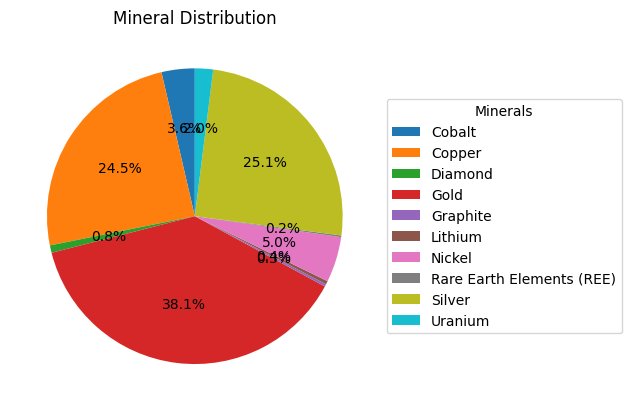

In [64]:
import matplotlib.pyplot as plt

# plt.figure()
# plt.pie(df_positives[targets].sum().values, labels=targets, autopct='%1.1f%%',
# startangle=100)
# plt.title("Mineral Distribution")

# plt.show()

plt.figure()
wedges, texts, autotexts = plt.pie( # type: ignore
    df_positives[targets].sum().values,
    autopct='%1.1f%%',
    startangle=90
)

plt.legend(
    wedges,
    targets,
    title="Minerals",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Mineral Distribution")
plt.show()

In [69]:
fig = go.Figure()

colors = px.colors.qualitative.Bold     

for i in range(len(targets)):
    mineral = targets[i]
    fig.add_trace(go.Scattermapbox(
        lat=df_positives[df_positives[mineral] == 1]["latitude"],
        lon=df_positives[df_positives[mineral] == 1]["longitude"],
        mode="markers",
        opacity=1,
        name=f"{mineral}",
        marker=dict(color=colors[i], size=6)
    ))

fig.add_trace(go.Scattermapbox(
    lat=df_negatives["latitude"],
    lon=df_negatives["longitude"],
    mode="markers",
    marker=dict(color=colors[len(targets)], size=6),
    opacity=0.5,
    name="Other minerals",
))

fig.update_layout(
    mapbox=dict(
        style="carto-positron",
        zoom=2.5,
        center=dict(lat=60, lon=-100)
    ),
    margin=dict(l=0, r=0, t=0, b=0),
    legend=dict(
        title=dict(text="Mine Type"),
        x=0.9,
        y=0.9,
        xanchor="right",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.8)"
    )
)

fig.show()

C:\Users\jylis\AppData\Local\Temp\ipykernel_2512\778371970.py:7: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
C:\Users\jylis\AppData\Local\Temp\ipykernel_2512\778371970.py:16: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


In [66]:
fig = go.Figure()

fig.add_trace(go.Scattermapbox(
    lat=df_positives["latitude"],
    lon=df_positives["longitude"],
    mode="markers",
    opacity=0.5,
    name="Mines with key minerals",
))

fig.add_trace(go.Scattermapbox(
    lat=df_negatives["latitude"],
    lon=df_negatives["longitude"],
    mode="markers",
    opacity=0.5,
    name="Mines without key minerals",
))

fig.update_layout(
    mapbox=dict(
        style="carto-positron",
        zoom=2.5,
        center=dict(lat=60, lon=-100)
    ),
    margin=dict(l=0, r=0, t=0, b=0),
    legend=dict(
        x=0.9,
        y=0.9,
        xanchor="right",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.8)"
    )
)

fig.show()

C:\Users\jylis\AppData\Local\Temp\ipykernel_2512\2969067844.py:3: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
C:\Users\jylis\AppData\Local\Temp\ipykernel_2512\2969067844.py:11: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
